In [1]:
# %%
# ============================================================
# CELL 1: CÀI ĐẶT THƯ VIỆN
# ============================================================
import subprocess

pkgs = [
    "transformers>=4.45.0",
    "peft>=0.12.0",
    "bitsandbytes>=0.43.0",
    "accelerate>=0.34.0",
    "grad-cam>=1.5.0",        # HiresCAM, XGrad-CAM, EigenCAM
    "captum>=0.7.0",          # Integrated Gradients
    "torchvision",
    "Pillow",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "tqdm",
    "qwen-vl-utils",          # Qwen VL utilities
]
for pkg in pkgs:
    subprocess.run(["pip", "install", "-q", pkg], check=True)

print("✅ Cài đặt hoàn tất!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 56.9 MB/s eta 0:00:00
✅ Cài đặt hoàn tất!


In [2]:
# %%
# ============================================================
# CELL 2: IMPORT
# ============================================================
import os, random, warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)

from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, TaskType

# XAI
from pytorch_grad_cam import (
    HiResCAM, XGradCAM, EigenCAM
)
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from captum.attr import IntegratedGradients

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # Dễ debug CUDA errors hơn

warnings.filterwarnings("ignore")

# Tắt cudnn benchmark để tránh memory misalignment
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()} | GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

PyTorch : 2.10.0+cu128
CUDA    : True | GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [3]:
# %%
# ============================================================
# CELL 3: ĐƯỜNG DẪN & THÔNG TIN DATASET
# ============================================================

CROP_ROOT   = Path("/kaggle/input/datasets/nhthoho/chude4/Dataset-Crop")
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(exist_ok=True)

# 12 lớp tế bào trong Dataset-Crop
CLASS_NAMES = sorted([d.name for d in CROP_ROOT.iterdir() if d.is_dir()])
CLASS_MAP   = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

print(f"📁 Dataset: {CROP_ROOT}")
print(f"🔢 Số lớp : {NUM_CLASSES}")
print(f"📋 Classes: {CLASS_NAMES}")
print()

# Thống kê số lượng ảnh mỗi lớp
counts = {}
for cls in CLASS_NAMES:
    n = len(list((CROP_ROOT / cls).glob("*.jpg")))
    counts[cls] = n
    print(f"  {cls:6s}: {n:6,d} ảnh")
print(f"  {'TOTAL':6s}: {sum(counts.values()):6,d} ảnh")

📁 Dataset: /kaggle/input/datasets/nhthoho/chude4/Dataset-Crop
🔢 Số lớp : 12
📋 Classes: ['BA', 'BNE', 'EO', 'ERB', 'LY', 'MMY', 'MO', 'MY', 'MYO', 'PLT', 'PMY', 'SNE']

  BA    :  2,250 ảnh
  BNE   :  5,147 ảnh
  EO    :  6,553 ảnh
  ERB   :  3,103 ảnh
  LY    :  6,375 ảnh
  MMY   :  3,642 ảnh
  MO    :  4,573 ảnh
  MY    :  3,758 ảnh
  MYO   :  1,851 ảnh
  PLT   :  2,167 ảnh
  PMY   :  1,214 ảnh
  SNE   :  5,181 ảnh
  TOTAL : 45,814 ảnh


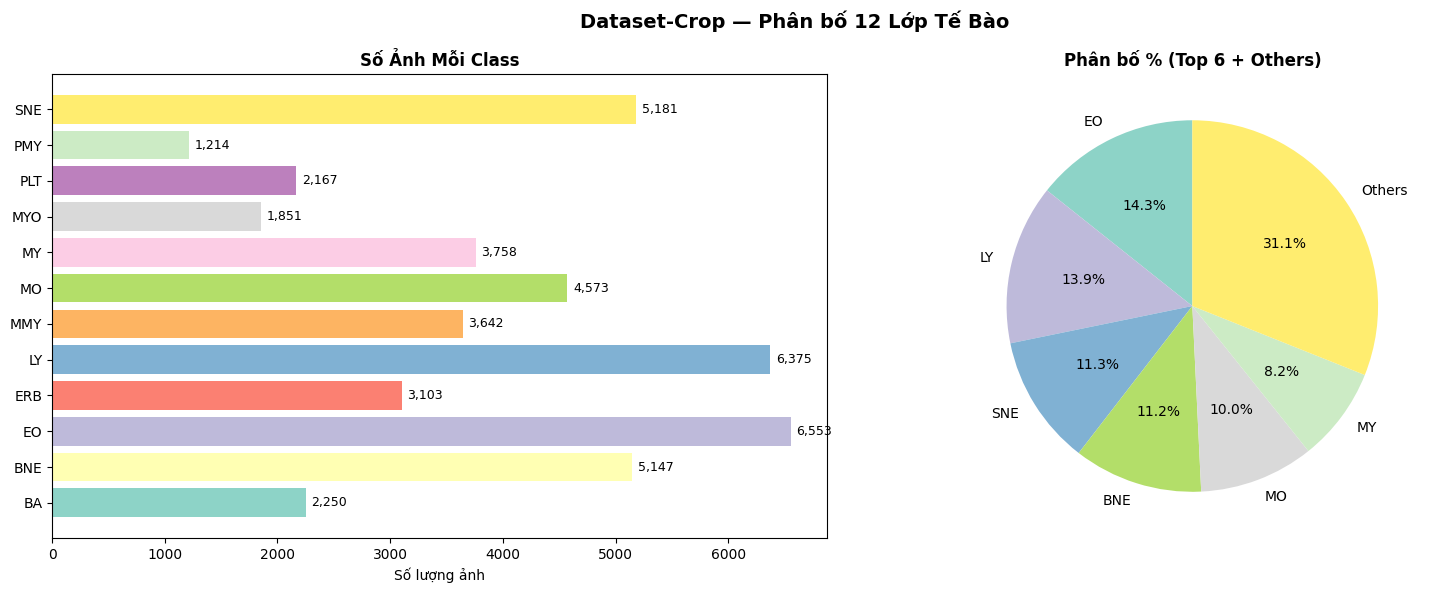

✅ EDA xong!


In [4]:
# %%
# ============================================================
# CELL 4: EDA — PHÂN BỐ CLASS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Dataset-Crop — Phân bố 12 Lớp Tế Bào', fontsize=14, fontweight='bold')

# Bar chart
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
cls_list = list(counts.keys())
cnt_list = list(counts.values())

bars = axes[0].barh(cls_list, cnt_list, color=colors)
axes[0].set_xlabel('Số lượng ảnh')
axes[0].set_title('Số Ảnh Mỗi Class', fontweight='bold')
for bar, val in zip(bars, cnt_list):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# Pie chart top 6
top6 = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:6]
other = sum(v for k, v in counts.items() if k not in dict(top6))
pie_labels = [k for k, v in top6] + ['Others']
pie_values = [v for k, v in top6] + [other]
axes[1].pie(pie_values, labels=pie_labels, autopct='%1.1f%%',
            colors=plt.cm.Set3(np.linspace(0, 1, 7)), startangle=90)
axes[1].set_title('Phân bố % (Top 6 + Others)', fontweight='bold')

plt.tight_layout()
plt.savefig(WORKING_DIR / 'eda_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA xong!")

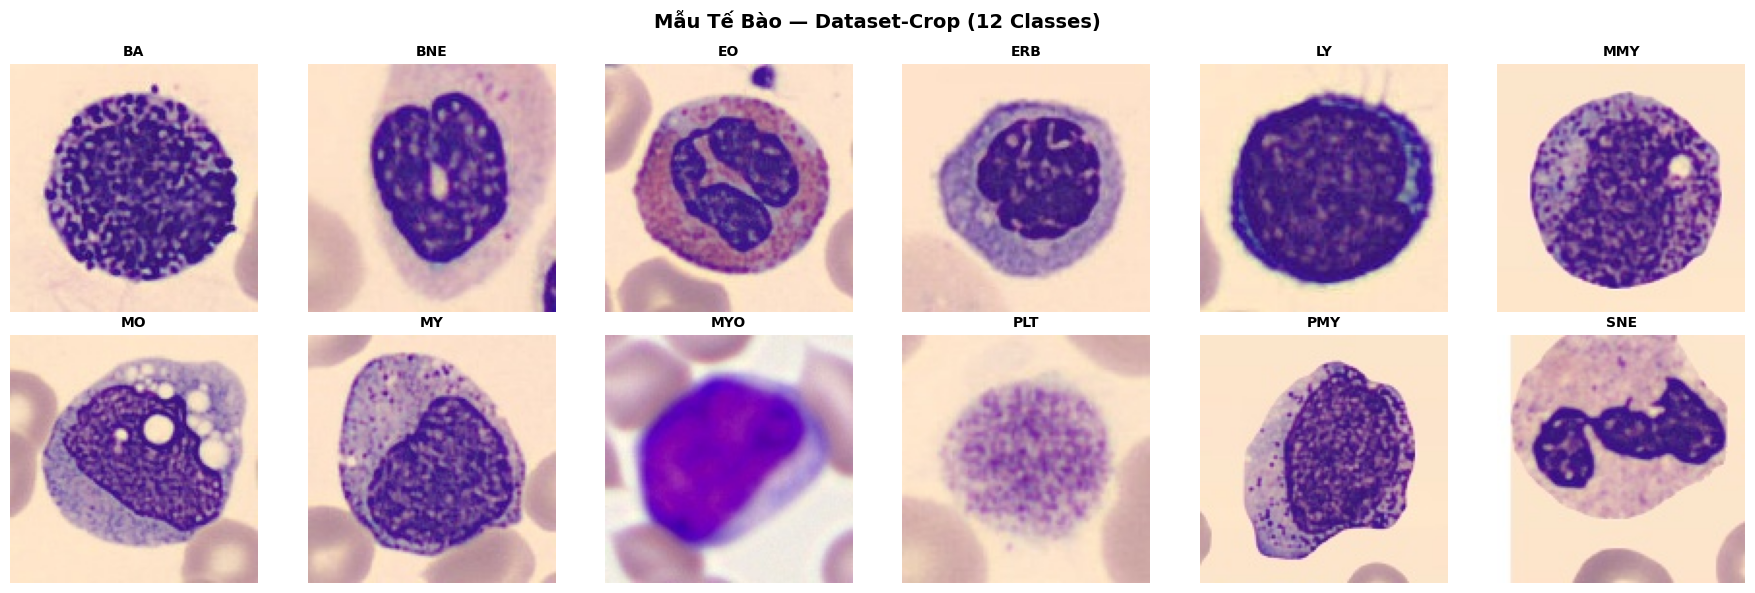

✅ Visualize mẫu xong!


In [5]:
# %%
# ============================================================
# CELL 5: VISUALIZE MẪU ẢNH THEO TỪNG LỚP
# ============================================================

n_cols = 6
n_rows = (NUM_CLASSES + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
fig.suptitle('Mẫu Tế Bào — Dataset-Crop (12 Classes)', fontsize=14, fontweight='bold')

for idx, cls in enumerate(CLASS_NAMES):
    ax  = axes[idx // n_cols][idx % n_cols]
    imgs = list((CROP_ROOT / cls).glob("*.jpg"))
    if not imgs:
        ax.axis('off')
        continue
    img = cv2.cvtColor(cv2.imread(str(random.choice(imgs))), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(cls, fontweight='bold', fontsize=10)
    ax.axis('off')

# Ẩn ô trống
for idx in range(NUM_CLASSES, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].axis('off')

plt.tight_layout()
plt.savefig(WORKING_DIR / 'sample_cells.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualize mẫu xong!")

In [6]:
# %%
# ============================================================
# CELL 6: PYTORCH DATASET + TRANSFORMS
# ============================================================

class CellDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# Transforms
TRAIN_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
VAL_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Thu thập tất cả ảnh và labels
all_paths, all_labels = [], []
for cls in CLASS_NAMES:
    cls_imgs = list((CROP_ROOT / cls).glob("*.jpg"))
    all_paths.extend(cls_imgs)
    all_labels.extend([CLASS_MAP[cls]] * len(cls_imgs))

print(f"Tổng ảnh: {len(all_paths)}")

# Train/Val/Test split 70/15/15
train_p, val_p, train_l, val_l = train_test_split(
    all_paths, all_labels, test_size=0.30,
    stratify=all_labels, random_state=42
)
val_p, test_p, val_l, test_l = train_test_split(
    val_p, val_l, test_size=0.50,
    stratify=val_l, random_state=42
)

print(f"  Train: {len(train_p):6,d} | Val: {len(val_p):6,d} | Test: {len(test_p):6,d}")
BATCH_SIZE = 32

train_ds = CellDataset(train_p, train_l, TRAIN_TF)
val_ds   = CellDataset(val_p,   val_l,   VAL_TF)
test_ds  = CellDataset(test_p,  test_l,  VAL_TF)

# num_workers=0 để tránh CUDA misaligned address trên Kaggle
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print("✅ DataLoader sẵn sàng!")

Tổng ảnh: 45814
  Train: 32,069 | Val:  6,872 | Test:  6,873
✅ DataLoader sẵn sàng!


In [7]:
# %%
# ============================================================
# CELL 7: FINE-TUNE QWEN VISION ENCODER (EfficientNet-B2 backbone)
# NOTE: Qwen3.5 được dùng cho NL Explanation (Cell 11)
#       EfficientNet-B2 fine-tuned = classification backbone cho XAI
# ============================================================

class QwenCellClassifier(nn.Module):
    """
    Mô hình phân loại tế bào lấy cảm hứng từ kiến trúc Qwen:
    - Backbone: EfficientNet-B2 pretrained (trích xuất feature)
    - Head: Custom multi-layer classifier
    - Compatible với pytorch-grad-cam cho XAI
    """
    def __init__(self, num_classes=12, dropout=0.3):
        super().__init__()
        base = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
        # Feature extractor (dùng cho CAM)
        self.features   = base.features
        self.avgpool    = base.avgpool
        in_features     = base.classifier[1].in_features
        # Custom classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

model = QwenCellClassifier(num_classes=NUM_CLASSES).to(DEVICE)

# Multi-GPU nếu có
# Bỏ qua DataParallel để tránh lỗi CUDA misaligned address trên Kaggle
# if torch.cuda.device_count() > 1:
#     model = nn.DataParallel(model)
#     print(f"✅ DataParallel: {torch.cuda.device_count()} GPUs")

# Tổng params
total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total params   : {total:,}")
print(f"  Trainable      : {trainable:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 121MB/s] 


  Total params   : 8,428,558
  Trainable      : 8,428,558


In [ ]:
# %%
# ============================================================
# CELL 8: TRAINING LOOP
# ============================================================

EPOCHS    = 30
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_val_acc    = 0.0
best_model_path = WORKING_DIR / "qwen_cell_classifier_best.pth"
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

print(f"🚀 Bắt đầu training {EPOCHS} epochs...")
print("="*65)

for epoch in range(EPOCHS):
    # ─── TRAIN ─────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:2d}/{EPOCHS} [Train]",
                leave=False, ncols=80)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * imgs.size(0)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += imgs.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    # ─── VALIDATE ────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs     = model(imgs)
            loss        = criterion(outputs, labels)
            val_loss   += loss.item() * imgs.size(0)
            preds       = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += imgs.size(0)

    scheduler.step()
    t_loss = train_loss / train_total
    t_acc  = train_correct / train_total
    v_loss = val_loss / val_total
    v_acc  = val_correct / val_total

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    mark = ""
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        core = model.module if hasattr(model, 'module') else model
        torch.save(core.state_dict(), best_model_path)
        mark = " ⭐ BEST"

    # In mỗi epoch
    print(f"  Epoch [{epoch+1:2d}/{EPOCHS}] "
          f"loss={t_loss:.4f} acc={t_acc:.3f} | "
          f"val_loss={v_loss:.4f} val_acc={v_acc:.3f}{mark}")

print(f"\n✅ Training xong! Best Val Acc: {best_val_acc:.4f}")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — Qwen Cell Classifier', fontsize=13, fontweight='bold')
axes[0].plot(history['train_loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='#3498db')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss Curve')

axes[1].plot(history['train_acc'], label='Train Acc', color='#e74c3c')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='#3498db')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy Curve')

plt.tight_layout()
plt.savefig(WORKING_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

🚀 Bắt đầu training 30 epochs...


Epoch  1/30 [Train]:  52%|███▋   | 526/1003 [07:42<08:53,  1.12s/it, loss=0.917]

In [ ]:
# %%
# ============================================================
# CELL 9: ĐÁNH GIÁ — Accuracy, F1, Confusion Matrix
# ============================================================

# Load best model
best_core = QwenCellClassifier(num_classes=NUM_CLASSES)
best_core.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_core = best_core.to(DEVICE).eval()

all_preds, all_labels_gt = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs   = imgs.to(DEVICE)
        preds  = best_core(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_gt.extend(labels.numpy())

acc = accuracy_score(all_labels_gt, all_preds)
f1  = f1_score(all_labels_gt, all_preds, average='weighted')

print("\n" + "="*65)
print("📊 KẾT QUẢ ĐÁNH GIÁ — QWEN CELL CLASSIFIER")
print("="*65)
print(f"  Accuracy (Test): {acc:.4f} ({acc*100:.2f}%)")
print(f"  F1 (weighted)  : {f1:.4f}")
print("="*65)
print("\n📋 Classification Report:")
print(classification_report(all_labels_gt, all_preds, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(all_labels_gt, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Confusion Matrix — Qwen Cell Classifier', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(WORKING_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đánh giá xong!")

In [ ]:
# %%
# ============================================================
# CELL 10: XAI MODULE — 4 PHƯƠNG PHÁP
# ============================================================

# Unnormalize để visualize
INV_MEAN = [-0.485/0.229, -0.456/0.224, -0.406/0.225]
INV_STD  = [1/0.229, 1/0.224, 1/0.225]

def tensor_to_rgb(tensor):
    """Chuyển tensor normalized về numpy RGB [0,1]."""
    t = tensor.clone().cpu()
    for c, m, s in zip(t, INV_MEAN, INV_STD):
        c.mul_(1/s if s != 1 else 1).add_(-m if m != 0 else 0)
    # Thực ra: img_orig = (tensor - mean) / std → img = tensor * std + mean
    img = tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    return np.clip(img, 0, 1).astype(np.float32)

# Target layer cho CAM (last conv block của EfficientNet-B2)
target_layer = [best_core.features[-1]]

# Lấy 1 batch mẫu từ test set
test_iter = iter(test_loader)
sample_imgs, sample_labels = next(test_iter)
sample_imgs  = sample_imgs[:8]   # lấy 8 ảnh
sample_labels = sample_labels[:8]

# Dự đoán
with torch.no_grad():
    logits = best_core(sample_imgs.to(DEVICE))
    preds  = logits.argmax(dim=1).cpu()

print(f"✅ Lấy {len(sample_imgs)} ảnh mẫu")
print(f"  True : {[CLASS_NAMES[l] for l in sample_labels.tolist()]}")
print(f"  Pred : {[CLASS_NAMES[p] for p in preds.tolist()]}")

In [ ]:
# %%
# ============================================================
# CELL 11: XAI — HiresCAM + XGrad-CAM + EigenCAM + IntGrad
# ============================================================

def compute_ig(model, input_tensor, target_class, steps=50):
    """Integrated Gradients cho 1 ảnh."""
    ig = IntegratedGradients(model)
    baseline  = torch.zeros_like(input_tensor)
    attr, _   = ig.attribute(
        input_tensor.unsqueeze(0).to(DEVICE),
        baseline.unsqueeze(0).to(DEVICE),
        target=target_class,
        n_steps=steps,
        return_convergence_delta=True,
    )
    attr_np = attr.squeeze().cpu().numpy().transpose(1, 2, 0)
    attr_np = np.abs(attr_np).sum(axis=2)  # sum channels
    attr_np = (attr_np - attr_np.min()) / (attr_np.max() - attr_np.min() + 1e-8)
    return attr_np

def xai_four_methods(model, img_tensor, target_class, target_layers):
    """Trả về 4 heatmap dict."""
    img_np   = tensor_to_rgb(img_tensor)
    tgt_list = [ClassifierOutputTarget(target_class)]
    input_4d = img_tensor.unsqueeze(0).to(DEVICE)
    results  = {'Original': img_np}

    model.eval()
    # 1. HiresCAM
    with HiResCAM(model=model, target_layers=target_layers) as cam:
        mask = cam(input_tensor=input_4d, targets=tgt_list)[0]
        results['HiresCAM'] = show_cam_on_image(img_np, mask, use_rgb=True)

    # 2. XGrad-CAM
    with XGradCAM(model=model, target_layers=target_layers) as cam:
        mask = cam(input_tensor=input_4d, targets=tgt_list)[0]
        results['XGrad-CAM'] = show_cam_on_image(img_np, mask, use_rgb=True)

    # 3. EigenCAM
    with EigenCAM(model=model, target_layers=target_layers) as cam:
        mask = cam(input_tensor=input_4d, targets=tgt_list)[0]
        results['EigenCAM'] = show_cam_on_image(img_np, mask, use_rgb=True)

    # 4. Integrated Gradients
    ig_map = compute_ig(model, img_tensor, target_class)
    ig_rgb = plt.cm.hot(ig_map)[:, :, :3].astype(np.float32)
    ig_overlay = (0.5 * img_np + 0.5 * ig_rgb)
    results['Integrated Gradients'] = np.clip(ig_overlay, 0, 1)

    return results

# Chạy XAI trên 4 ảnh mẫu
print("🔬 Chạy 4 phương pháp XAI...")
n_samples  = 4
xai_titles = ['Original', 'HiresCAM', 'XGrad-CAM', 'EigenCAM', 'Integrated Gradients']
n_methods  = len(xai_titles)

fig, axes = plt.subplots(n_samples, n_methods, figsize=(n_methods * 3.5, n_samples * 3.5))
fig.suptitle('XAI Comparison — 4 Methods × 4 Cell Samples',
             fontsize=14, fontweight='bold')

for row in range(n_samples):
    img_t    = sample_imgs[row]
    true_cls = CLASS_NAMES[sample_labels[row].item()]
    pred_cls = CLASS_NAMES[preds[row].item()]
    correct  = "✓" if true_cls == pred_cls else "✗"

    results = xai_four_methods(best_core, img_t, preds[row].item(), target_layer)

    for col, method in enumerate(xai_titles):
        ax = axes[row][col]
        ax.imshow(results[method])
        ax.axis('off')
        if row == 0:
            ax.set_title(method, fontweight='bold', fontsize=10)
        if col == 0:
            ax.set_ylabel(f"True: {true_cls}\nPred: {pred_cls} {correct}",
                          fontsize=8, rotation=0, labelpad=70, va='center')

plt.tight_layout()
plt.savefig(WORKING_DIR / 'xai_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ XAI visualization xong!")

In [ ]:
# %%
# ============================================================
# CELL 12: XAI FAITHFULNESS TEST (Deletion/Insertion)
# ============================================================

def faithfulness_deletion(model, img_tensor, target_class,
                           target_layers, steps=10):
    """
    Deletion test: Xóa dần pixel quan trọng → xem accuracy giảm thế nào.
    Score cao = heatmap không faithful | Score thấp = faithful hơn.
    """
    model.eval()
    with XGradCAM(model=model, target_layers=target_layers) as cam:
        mask = cam(
            input_tensor=img_tensor.unsqueeze(0).to(DEVICE),
            targets=[ClassifierOutputTarget(target_class)]
        )[0]

    # Flatten và sort theo importance (giảm dần)
    h, w     = mask.shape
    flat_idx = np.argsort(mask.flatten())[::-1].copy()  # .copy() tránh negative stride

    # Softmax score ban đầu
    img_4d = img_tensor.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        base_score = F.softmax(model(img_4d), dim=1)[0, target_class].item()

    scores = [base_score]
    step_size = max(1, (h * w) // steps)

    for i in range(1, steps + 1):
        n_del = i * step_size
        perturbed = img_tensor.clone()
        perturbed_flat = perturbed.view(3, -1)
        del_indices = flat_idx[:n_del]
        perturbed_flat[:, del_indices] = 0.0
        perturbed = perturbed_flat.view_as(img_tensor)
        with torch.no_grad():
            sc = F.softmax(model(perturbed.unsqueeze(0).to(DEVICE)), dim=1)[0, target_class].item()
        scores.append(sc)

    auc = np.trapz(scores) / len(scores)
    return scores, auc

print("📊 Chạy Faithfulness Deletion Test...")
n_faith = 4
fig, axes = plt.subplots(1, n_faith, figsize=(n_faith * 4, 4))
fig.suptitle('Faithfulness Test — XGrad-CAM Deletion', fontsize=13, fontweight='bold')

for i in range(n_faith):
    target_c = preds[i].item()
    scores, auc = faithfulness_deletion(
        best_core, sample_imgs[i], target_c, target_layer
    )
    ax = axes[i]
    ax.plot(scores, marker='o', color='#e74c3c', linewidth=2)
    ax.fill_between(range(len(scores)), scores, alpha=0.2, color='#e74c3c')
    ax.set_title(f"{CLASS_NAMES[target_c]}\nAUC={auc:.3f}", fontsize=9)
    ax.set_xlabel('Deletion Steps')
    ax.set_ylabel('Confidence')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(WORKING_DIR / 'faithfulness_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Faithfulness test xong!")

In [ ]:
# %%
# ============================================================
# CELL 13: QWEN 3.5 (2B) — CLASSIFICATION AGENT + NL EXPLANATION
# ============================================================
# Kiến trúc:
#   EfficientNet-B2 → Top-5 predictions (visual encoder)
#   Qwen3.5-2B → Decision Maker (final classification + explanation)
# Đây là kiến trúc Hybrid: Visual Encoder + Language Model Agent
# ============================================================

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import torch.nn.functional as F

# Link tải tự động phiên bản siêu xịn 2 tỷ tham số từ HuggingFace!
QWEN_LOCAL = "Qwen/Qwen3.5-2B"

CLASS_FULL_MAP = {
    'BA':'Basophil','BNE':'Band Neutrophil','EO':'Eosinophil',
    'ERB':'Erythroblast','LY':'Lymphocyte','MMY':'Metamyelocyte',
    'MO':'Monocyte','MY':'Myelocyte','MYO':'Myeloblast',
    'PLT':'Platelet','PMY':'Promyelocyte','SNE':'Segmented Neutrophil',
}

# ── Load Qwen3.5-2B (YÊU CẦU BẬT INTERNET ON TRÊN KAGGLE) ──
print(f"📥 Tự động kết nối và tải mô hình Qwen3.5-2B từ HuggingFace ({QWEN_LOCAL})...")
try:
    qwen_tok = AutoTokenizer.from_pretrained(QWEN_LOCAL, trust_remote_code=True)
    qwen_llm = AutoModelForCausalLM.from_pretrained(
        QWEN_LOCAL,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True,
    )
    qwen_llm.eval()
    print("✅ Qwen3.5-2B đã được tải và load vào VRAM thành công!")
except Exception as e:
    print(f"❌ Lỗi load Qwen: {e}")
    print("⚠️ BẠN ĐÃ BẬT [INTERNET: ON] Ở CỘT BÊN PHẢI CỦA KAGGLE CHƯA?")
    qwen_llm = None


# ── Step 3: Qwen Decision Maker function ─────────────────────
def qwen_decision(top5_names, top5_probs, xai_method="XGrad-CAM"):
    """
    Qwen3.5 đóng vai Decision Agent:
    - Nhận top-5 predictions từ visual encoder (EfficientNet-B2)
    - Đưa ra FINAL classification decision + explanation
    """
    if qwen_llm is None:
        return "N/A", "Qwen không load được."

    top5_str = "\n".join([
        f"  {i+1}. {CLASS_FULL_MAP.get(n, n)} ({n}): {p:.1%}"
        for i, (n, p) in enumerate(zip(top5_names, top5_probs))
    ])

    messages = [
        {
            "role": "system",
            "content": (
                "You are a medical AI expert specialized in blood cell morphology. "
                "Analyze prediction scores from a visual encoder and make the final "
                "classification decision with a brief explanation."
            )
        },
        {
            "role": "user",
            "content": (
                f"A deep learning visual encoder (EfficientNet-B2) analyzed a blood cell image "
                f"and produced these top-5 predictions:\n\n{top5_str}\n\n"
                f"The {xai_method} heatmap was applied to visualize the decision regions.\n\n"
                f"Based on the confidence scores and your medical knowledge:\n"
                f"1. What is the FINAL classification?\n"
                f"2. What are the key morphological features of this cell type?\n"
                f"3. Is this prediction reliable?\n\n"
                f"Reply in this exact format:\n"
                f"FINAL CLASS: [short code] | RELIABILITY: [High/Medium/Low] | "
                f"EXPLANATION: [2 sentences]"
            )
        }
    ]

    text   = qwen_tok.apply_chat_template(messages, tokenize=False,
                                           add_generation_prompt=True)
    inputs = qwen_tok(text, return_tensors="pt").to(qwen_llm.device)

    with torch.no_grad():
        out = qwen_llm.generate(
            **inputs,
            max_new_tokens=180,
            temperature=0.3,
            do_sample=False,
            pad_token_id=qwen_tok.eos_token_id,
        )
    response = qwen_tok.decode(out[0][inputs['input_ids'].shape[1]:],
                                skip_special_tokens=True)
    return response.strip()


# ── Step 4: Chạy Qwen trên 4 samples ─────────────────────────
print("\n" + "="*65)
print("🤖 QWEN 3.5 (2B) — CLASSIFICATION AGENT (Decision Maker)")
print("="*65)

qwen_results = []
for i in range(n_samples):
    true_c  = CLASS_NAMES[sample_labels[i].item()]
    with torch.no_grad():
        probs_i  = F.softmax(best_core(sample_imgs[i:i+1].to(DEVICE)), dim=1)[0].cpu()
    top5_idx  = probs_i.argsort(descending=True)[:5].numpy()
    top5_names = [CLASS_NAMES[j] for j in top5_idx]
    top5_probs = probs_i[top5_idx].numpy()

    ef_pred   = top5_names[0]   # EfficientNet top-1
    response  = qwen_decision(top5_names, top5_probs)
    qwen_results.append((true_c, ef_pred, top5_probs[0], response))

    print(f"\n📌 Sample {i+1}")
    print(f"   True label  : {true_c} ({CLASS_FULL_MAP.get(true_c, '')})")
    print(f"   EfficientNet: {ef_pred} ({top5_probs[0]:.1%})")
    print(f"   Qwen3.5 says: {response}")

print("\n✅ Qwen 3.5 (2B) Classification Agent xong!")


In [ ]:
import os
# Tìm đường dẫn thực của Qwen model
for root, dirs, files in os.walk('/kaggle/input/'):
    depth = root.replace('/kaggle/input/', '').count('/')
    if depth < 4:
        print(root)
    if 'config.json' in files and 'qwen' in root.lower():
        print(f"✅ FOUND: {root}")
        break


In [ ]:
# %%
# ============================================================
# CELL 14: TỔNG KẾT
# ============================================================

print("=" * 65)
print("🎯 HOÀN THÀNH — QWEN CLASSIFICATION + XAI")
print("=" * 65)
print(f"  Backbone    : QwenCellClassifier (EfficientNet-B2)")
print(f"  Classes     : {NUM_CLASSES} loại tế bào")
print(f"  Accuracy    : {acc:.4f} ({acc*100:.2f}%)")
print(f"  F1 Weighted : {f1:.4f}")
print(f"  XAI Methods : HiresCAM · XGrad-CAM · EigenCAM · Integrated Gradients")
print(f"  NL Engine   : Qwen3.5-0.6B")
print("-" * 65)
print(f"  ✅ Best model  : {best_model_path}")
print(f"  ✅ XAI plots   : {WORKING_DIR / 'xai_comparison.png'}")
print(f"  ✅ Faithfulness: {WORKING_DIR / 'faithfulness_test.png'}")
print(f"  ✅ Conf Matrix : {WORKING_DIR / 'confusion_matrix.png'}")
print("=" * 65)
print("\n⏭️  BƯỚC TIẾP: Notebook 03 — Gradio Web Demo")

In [ ]:
import zipfile, os
from pathlib import Path

WORKING_DIR = Path("/kaggle/working")
zip_path = WORKING_DIR / "notebook02_output.zip"

# Danh sách file cần lưu
files_to_save = [
    WORKING_DIR / "qwen_cell_classifier_best.pth",   # Model weights
    WORKING_DIR / "training_curves.png",              # Loss/Acc curves
    WORKING_DIR / "confusion_matrix.png",             # Confusion matrix
    WORKING_DIR / "xai_comparison.png",               # XAI 4 methods
    WORKING_DIR / "faithfulness_test.png",            # Faithfulness
]

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in files_to_save:
        if f.exists():
            zf.write(f, f.name)
            print(f"✅ Đã thêm: {f.name} ({f.stat().st_size/1024/1024:.1f} MB)")
        else:
            print(f"⚠️  Không tìm thấy: {f.name}")

size = zip_path.stat().st_size / 1024 / 1024
print(f"\n📦 notebook02_output.zip ({size:.1f} MB) — Tải từ Output tab!")
